In [65]:
import pandas as pd
import numpy as np

# Load the DataFrame
df = pd.read_csv("common_strains_with_multiple_contigs.csv", index_col=0, dtype=str)

# Determine the number of rows per split
num_splits = 5
split_size = int(np.ceil(len(df) / num_splits))

# Split the DataFrame into 5 separate DataFrames
df1, df2, df3, df4, df5 = [df.iloc[i * split_size:(i + 1) * split_size] for i in range(num_splits)]

# Print number of rows in each split
print(f"df1: {len(df1)} rows")
print(f"df2: {len(df2)} rows")
print(f"df3: {len(df3)} rows")
print(f"df4: {len(df4)} rows")
print(f"df5: {len(df5)} rows")


df1: 54790 rows
df2: 54790 rows
df3: 54790 rows
df4: 54790 rows
df5: 54786 rows


In [26]:
import pandas as pd

# Example DataFrame

# 1. Filter rows where contigs_patric and contig_count are the same
same_df = df[df['contigs_patric'] == df['contig_count']]

# 2. Filter rows where contigs_patric and contig_count are not the same
not_same_df = df[df['contigs_patric'] != df['contig_count']]

# 3. Count occurrences of each number where both are the same
same_counts = same_df['contigs_patric'].value_counts().reset_index(name='count')
same_counts.columns = ['value', 'same_count']

# 4. Count how many rows where contigs_patric and contig_count are not the same
not_same_count = not_same_df.shape[0]

# 5. Combine the results into one table using pd.concat
not_same_df = pd.DataFrame([{'value': 'Not Same', 'same_count': not_same_count}])
summary = pd.concat([same_counts, not_same_df], ignore_index=True)

# 6. Display the summary
summary.to_csv('summary.csv',index=False)


KeyboardInterrupt: 

In [27]:
df2

,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
58099,1396,MYb220,1396.2140,39,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,39
58100,1396,N1,1396.2791,1302,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1302
58101,1396,N10,1396.2785,191,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,191
58102,1396,N13,1396.2786,132,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,132
58103,1396,N16,1396.2783,215,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,215
...,...,...,...,...,...,...
117721,210,22390,210.2962,56,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,56
117722,210,22393,210.2972,130,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,130
117723,210,22395,210.2959,215,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,215
117724,210,22402,210.2960,48,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,48


In [28]:
import pandas as pd

# Assuming df is your DataFrame
# Create boolean conditions for each of the two scenarios
condition_1 = df['contigs_patric']!=df['contig_count'] 


# Combine both conditions using the logical OR operator
filtered_df = df[condition_1]

# Display the filtered DataFrame
filtered_df


,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
8,1000565,FAM5,1000565.3,60,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,58
13,1000570,DSM 20563,1000570.8,14,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,16
20,1000952,HC-17A2,1000952.3,136,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,135
30,1001586,Mallika,1001586.3,335,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,41
31,1001588,2002000621,1001588.3,220,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,71
...,...,...,...,...,...,...
295024,999430,ATCC 35404,999430.5,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,33
295025,999431,H1-T,999431.4,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,26
295026,999432,H-22,999432.5,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,21
295028,999434,OTK,999434.4,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,11


In [29]:
filtered_df.to_csv("10k_diff.csv")

In [30]:
import pandas as pd

# Assuming df2 is your DataFrame
# Ensure contig_count is an integer
df2['contig_count'] = df2['contig_count'].astype(int)

# Create condition for genomes with exactly 4 contigs
condition_4 = df2['contig_count'] == 4

# Filter the DataFrame based on the condition
filtered_4_df = df2[condition_4]

# Display the filtered DataFrame (optional)
print(filtered_4_df)

# Count how many genomes meet the condition (contig_count == 4)
num_genomes_4 = filtered_4_df.shape[0]

# Display the count
print(f'Number of genomes with exactly 4 contigs: {num_genomes_4}')


       taxon_id   strain   genome_id contigs_patric  \
58116      1396   N435-1   1396.3261              4   
58121      1396     NJ-W    1396.462              4   
58131      1396      P12   1396.4430              4   
58151      1396     S-25   1396.4255              4   
58152      1396     S2-8    1396.150              4   
...         ...      ...         ...            ...   
117303   208962  RM10507  208962.296              4   
117311   208962   RM9976  208962.297              4   
117466     2097    85276     2097.64              4   
117557  2099788  CBA3605   2099788.3              4   
117558  2099789  CBA3606   2099789.3              4   

                                                 ftp_path  contig_count  
58116   https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...             4  
58121   https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...             4  
58131   https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...             4  
58151   https://ftp.ncbi.nlm.nih.gov/genome

/var/folders/65/rjhnld5s4xv_rsh25jvbsq5r0000gp/T/ipykernel_7516/589382892.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['contig_count'] = df2['contig_count'].astype(int)


In [ ]:
import pandas as pd

# Assuming df is your DataFrame
# Create boolean conditions for each of the two scenarios
condition_1 = (df['contigs_patric'] == '1') & (df['contig_count'] == '2')
condition_2 = (df['contigs_patric'] == '2') & (df['contig_count'] == '1')

# Combine both conditions using the logical OR operator
filtered_df = df[condition_1 | condition_2]

# Display the filtered DataFrame
filtered_df

,taxon_id,strain,genome_id,contigs_patric,ftp_path,contig_count
147,1004786,AltDE1,1004786.12,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
148,1004787,Balearic Sea AD45,1004787.19,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
346,1006155,WS 4560,1006155.9,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,1
429,1009856,USDA,1009856.5,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
430,1009857,W106,1009857.5,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
...,...,...,...,...,...,...
291499,907237,Lithuania75,907237.6,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
291820,91891,Lorraine,91891.50,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
293502,96345,160401-1/5N,96345.197,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2
293731,96901,BG33R,96901.3,1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2


In [32]:
import pandas as pd

# Assuming df is your DataFrame
filtered_df = df[df['contigs_patric'] != df['contig_count']]

# Display the filtered DataFrame
print(filtered_df)


       taxon_id          strain  genome_id contigs_patric  \
8       1000565            FAM5  1000565.3             60   
13      1000570       DSM 20563  1000570.8             14   
20      1000952         HC-17A2  1000952.3            136   
30      1001586         Mallika  1001586.3            335   
31      1001588      2002000621  1001588.3            220   
...         ...             ...        ...            ...   
295024   999430      ATCC 35404   999430.5              1   
295025   999431            H1-T   999431.4              1   
295026   999432            H-22   999432.5              1   
295028   999434             OTK   999434.4              1   
295044   999552  DSM 14336; MB2  999552.18              1   

                                                 ftp_path contig_count  
8       https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...           58  
13      https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...           16  
20      https://ftp.ncbi.nlm.nih.gov/genomes/all

In [33]:
import pandas as pd

df = pd.read_csv('results/2_multiple_xml_filenames.csv', on_bad_lines='skip')  # Skip rows with too many fields
df.head(5).to_csv("genomes.csv")


In [ ]:
import pandas as pd
patric = pd.read_csv("genome_metadata", sep='\t',dtype=str)
patric[patric['genome_id']=='1006.10']['genome_length']

471346    4535079
Name: genome_length, dtype: object

In [ ]:
Total 8844. The percentage for 7963 is approximately 90.04%, and the percentage for 881 is approximately 9.96%

In [35]:
import pandas as pd

df = pd.read_csv("results/2to2results.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Perform the comparison
condition = df['n_of_1'] == df['subject_length']
df_matched = df[condition]

df_matched


,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_-1,n_of_0,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename
0,22,1001240,DSM 21065,1001240.6,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001240.6.fna,GCF_014200405.1_ASM1420040v1_genomic.fna,4531652,...,0,0,4531652,0,0,0,0,0,0,1001240_subject_array_1738727576.bin
1,27,1001582,LL3,1001582.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001582.3.fna,GCF_000204275.1_ASM20427v1_genomic.fna,4001985,...,0,0,4001985,0,0,0,0,0,0,1001582_subject_array_1738727578.bin
2,40,1001705,1S-152-0914,1001705.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1001705.3.fna,GCF_000271285.1_ASM27128v1_genomic.fna,4897666,...,0,0,4897666,0,0,0,0,0,0,1001705_subject_array_1738727579.bin
3,91,100225,LK16-18,100225.4,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,100225.4.fna,GCF_003391095.1_ASM339109v1_genomic.fna,3631970,...,0,0,3631970,0,0,0,0,0,0,100225_subject_array_1738727581.bin
4,106,1002795,MB620,1002795.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1002795.3.fna,GCF_015732155.1_ASM1573215v1_genomic.fna,2691682,...,0,0,2691682,0,0,0,0,0,0,1002795_subject_array_1738727582.bin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8839,294847,996558,FSL M8-0129,996558.21,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,996558.21.fna,GCF_038039325.1_ASM3803932v1_genomic.fna,4138431,...,0,0,4138431,0,0,0,0,0,0,996558_subject_array_1738743379.bin
8840,294850,996558,FSL W8-1055,996558.24,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,996558.24.fna,GCF_039409915.1_ASM3940991v1_genomic.fna,4047303,...,0,0,4047303,0,0,0,0,0,0,996558_subject_array_1738743381.bin
8841,294991,998674,DSM 2157,998674.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,998674.3.fna,GCF_000419525.1_ASM41952v1_genomic.fna,5185674,...,0,0,5185674,0,0,0,0,0,0,998674_subject_array_1738743383.bin
8842,295053,999931,39T,999931.5,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/9...,2,999931.5.fna,GCF_910573815.1_Bh_39T_genomic.fna,3622728,...,0,0,3622728,0,0,0,0,0,0,999931_subject_array_1738743384.bin


In [ ]:
import pandas as pd

df = pd.read_csv("results/2to2results.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Create matched and unmatched DataFrames
matched_df = df[df['n_of_1'] == df['subject_length']]
unmatched_df = df[df['n_of_1'] != df['subject_length']]


unmatched_df


,col1,col2,col3,col4,col5,col6,col7,query_fna,subject_fna,query_length,...,n_of_-1,n_of_0,n_of_1,n_of_2,n_of_3,n_of_4,n_of_5,n_of_6,n_of_7,binary_filename
5,107,1002804,CIII-1,1002804.6,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1002804.6.fna,GCF_000237285.1_ASM23728v1_genomic.fna,1807534,...,0,9154,1798380,0,0,0,0,0,0,1002804_subject_array_1738727583.bin
12,319,1005665,FY-07,1005665.11,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1005665.11.fna,GCF_027886705.1_ASM2788670v1_genomic.fna,13963,...,0,5118956,13963,0,0,0,0,0,0,1005665_subject_array_1738727598.bin
30,887,102886,LBVP101/21,102886.11,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,102886.11.fna,GCF_030848225.1_ASM3084822v1_genomic.fna,1983925,...,0,183,1983742,0,0,0,0,0,0,102886_subject_array_1738727626.bin
35,967,1032070,LMG 9904,1032070.5,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1032070.5.fna,GCF_006165035.1_ASM616503v1_genomic.fna,2107083,...,0,2008,2105075,0,0,0,0,0,0,1032070_subject_array_1738727631.bin
56,1286,1038922,Q2-87,1038922.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,1038922.3.fna,GCF_000281895.1_ASM28189v1_genomic.fna,6367968,...,0,170,5,0,0,2,6367991,0,0,1038922_subject_array_1738727704.bin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8781,292500,940139,03SUJ4,940139.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,940139.3.fna,GCF_046263735.1_ASM4626373v1_genomic.fna,4163374,...,0,80313,1140,0,0,1,4163240,0,5,940139_subject_array_1738743281.bin
8788,292622,94138,DRD-90,94138.32,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,94138.32.fna,GCF_030970965.1_ASM3097096v1_genomic.fna,2533843,...,0,1700,2532143,0,0,0,0,0,0,94138_subject_array_1738743293.bin
8789,292674,943346,KB1,943346.3,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,943346.3.fna,GCF_007830295.1_ASM783029v1_genomic.fna,6057612,...,1,2855,6054667,0,2,32,55,0,0,943346_subject_array_1738743295.bin
8795,293179,95486,FDAARGOS_720,95486.464,2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,2,95486.464.fna,GCF_012273415.1_ASM1227341v1_genomic.fna,7247662,...,0,199,7247463,0,0,0,0,0,0,95486_subject_array_1738743305.bin


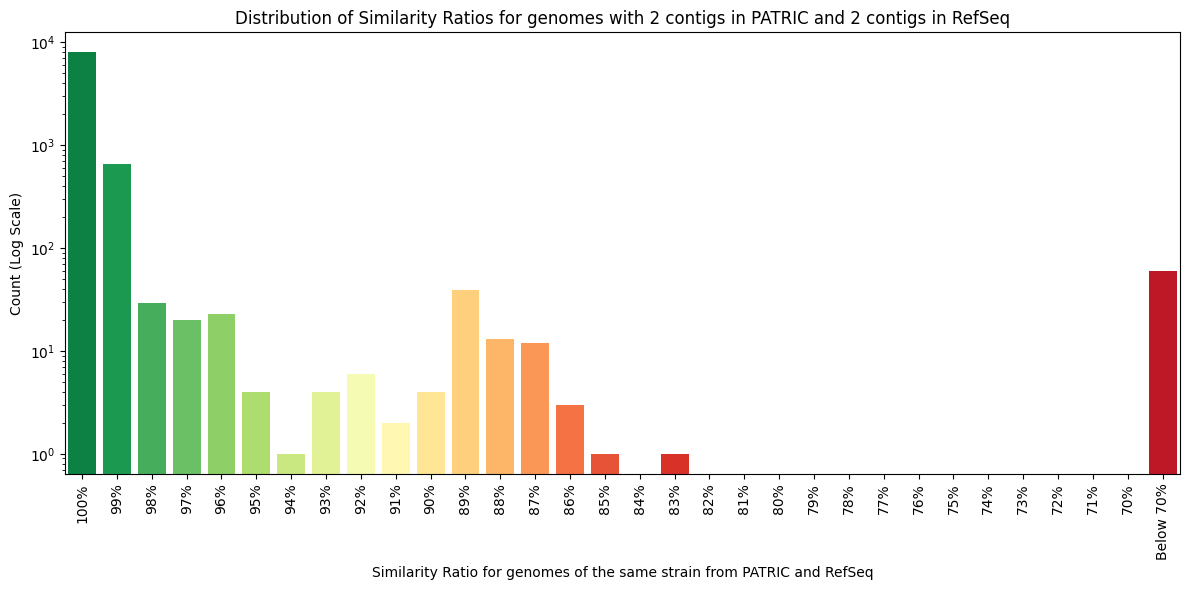

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read the CSV
df = pd.read_csv("results/2to2results.csv", dtype='str')

# Convert columns to numeric
df['n_of_1'] = pd.to_numeric(df['n_of_1'], errors='coerce')
df['subject_length'] = pd.to_numeric(df['subject_length'], errors='coerce')

# Compute ratio
df['ratio'] = df['n_of_1'] / df['subject_length']

# Define a function to categorize the ratios
def categorize_ratio(ratio):
    if ratio == 1.0:
        return '100%'  # Change from '1.0' to '100%'
    elif 0.99 < ratio < 1.0:
        return '99%'
    elif 0.98 < ratio < 0.99:
        return '98%'
    elif 0.97 < ratio < 0.98:
        return '97%'
    elif 0.96 < ratio < 0.97:
        return '96%'
    elif 0.95 < ratio < 0.96:
        return '95%'
    elif 0.94 < ratio < 0.95:
        return '94%'
    elif 0.93 < ratio < 0.94:
        return '93%'
    elif 0.92 < ratio < 0.93:
        return '92%'
    elif 0.91 < ratio < 0.92:
        return '91%'
    elif 0.9 < ratio < 0.91:
        return '90%'
    elif 0.89 < ratio < 0.90:
        return '89%'
    elif 0.88 < ratio < 0.89:
        return '88%'
    elif 0.87 < ratio < 0.88:
        return '87%'
    elif 0.86 < ratio < 0.87:
        return '86%'
    elif 0.85 < ratio < 0.86:
        return '85%'
    elif 0.84 < ratio < 0.85:
        return '84%'
    elif 0.83 < ratio < 0.84:
        return '83%'
    elif 0.82 < ratio < 0.83:
        return '82%'
    elif 0.81 < ratio < 0.82:
        return '81%'
    elif 0.8 < ratio < 0.81:
        return '80%'
    elif 0.79 < ratio < 0.80:
        return '79%'
    elif 0.78 < ratio < 0.79:
        return '78%'
    elif 0.77 < ratio < 0.78:
        return '77%'
    elif 0.76 < ratio < 0.77:
        return '76%'
    elif 0.75 < ratio < 0.76:
        return '75%'
    elif 0.74 < ratio < 0.75:
        return '74%'
    elif 0.73 < ratio < 0.74:
        return '73%'
    elif 0.72 < ratio < 0.73:
        return '72%'
    elif 0.71 < ratio < 0.72:
        return '71%'
    elif 0.7 < ratio < 0.71:
        return '70%'
    else:
        return 'Below 70%'

# Apply the categorization
df['ratio_category'] = df['ratio'].apply(categorize_ratio)

# Count occurrences per category
category_counts = df['ratio_category'].value_counts()

# Define a custom color palette
custom_palette = sns.color_palette("RdYlGn_r", n_colors=len(category_counts))

# Plot the data with Seaborn countplot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='ratio_category', data=df, order=[
    '100%', '99%', '98%', '97%', '96%', '95%', '94%', 
    '93%', '92%', '91%', '90%', '89%', '88%', 
    '87%', '86%', '85%', '84%', '83%', '82%', 
    '81%', '80%', '79%', '78%', '77%', '76%', 
    '75%', '74%', '73%', '72%', '71%', '70%', 
    'Below 70%'
])

# Apply the custom palette to the bars
for p, color in zip(ax.patches, custom_palette):
    p.set_facecolor(color)

# Customize the plot
plt.xticks(rotation=90)
plt.xlabel('Similarity Ratio for genomes of the same strain from PATRIC and RefSeq')
plt.ylabel('Count (Log Scale)')
plt.title('Distribution of Similarity Ratios for genomes with 2 contigs in PATRIC and 2 contigs in RefSeq')
plt.yscale('log')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
df = pd.read_csv("common_strains_with_multiple_contigs.csv",dtype=str)
condition = (df['contig_count']=='3') & (df['contigs_patric']=='3')
df[condition].to_csv("genomes.csv",index=False)